# Laboratorio 10
## EDA

##### Importación de librerías.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.model_selection import train_test_split

##### Importación de datos.

In [3]:
df = pd.read_csv('titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


##### Cantidad de datos.

In [4]:
df.shape

(418, 12)

##### Datos faltantes y tipos.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


In [6]:
df['Cabin'].unique()

array([nan, 'B45', 'E31', 'B57 B59 B63 B66', 'B36', 'A21', 'C78', 'D34',
       'D19', 'A9', 'D15', 'C31', 'C23 C25 C27', 'F G63', 'B61', 'C53',
       'D43', 'C130', 'C132', 'C101', 'C55 C57', 'B71', 'C46', 'C116',
       'F', 'A29', 'G6', 'C6', 'C28', 'C51', 'E46', 'C54', 'C97', 'D22',
       'B10', 'F4', 'E45', 'E52', 'D30', 'B58 B60', 'E34', 'C62 C64',
       'A11', 'B11', 'C80', 'F33', 'C85', 'D37', 'C86', 'D21', 'C89',
       'F E46', 'A34', 'D', 'B26', 'C22 C26', 'B69', 'C32', 'B78',
       'F E57', 'F2', 'A18', 'C106', 'B51 B53 B55', 'D10 D12', 'E60',
       'E50', 'E39 E41', 'B52 B54 B56', 'C39', 'B24', 'D28', 'B41', 'C7',
       'D40', 'D38', 'C105'], dtype=object)

Note que Cabin tiene datos, pero al ser una variable nominal, no se considerará para este laboratorio. Age y Fare también tiene datos nulos, se decidirá posteriormente que hacer con estos.

##### Eliminando variables no útiles.

In [7]:
df = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])

##### Balance de clases.

In [8]:
# Sobrevivió
df['Survived'].value_counts()

Survived
0    266
1    152
Name: count, dtype: int64

In [9]:
# Clase del húesped
df['Pclass'].value_counts()

Pclass
3    218
1    107
2     93
Name: count, dtype: int64

In [10]:
# Sexo
df['Sex'].value_counts()

Sex
male      266
female    152
Name: count, dtype: int64

In [11]:
# Lugar de embarcación
df['Embarked'].value_counts()

Embarked
S    270
C    102
Q     46
Name: count, dtype: int64

No existe balance en ninguna de las columnas categóricas.

##### Histogramas y estadísticas.

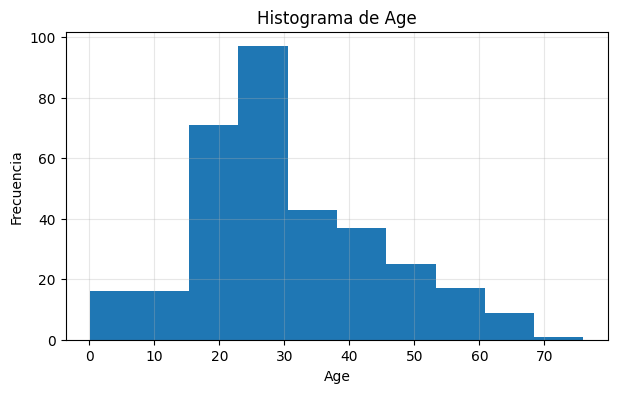

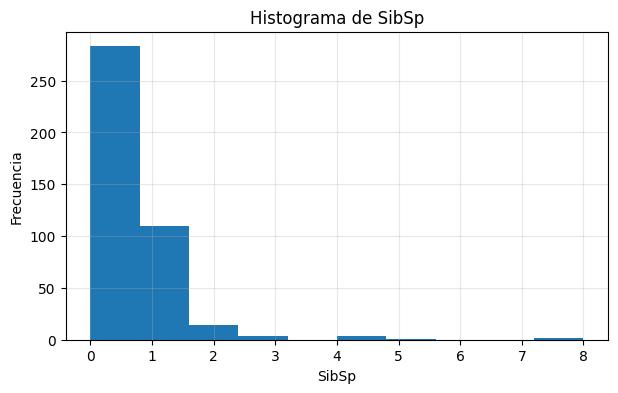

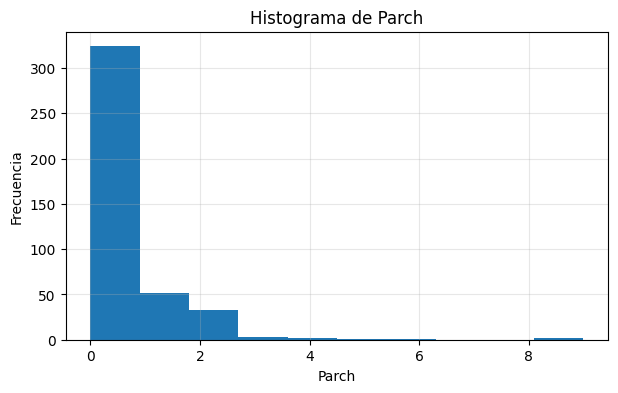

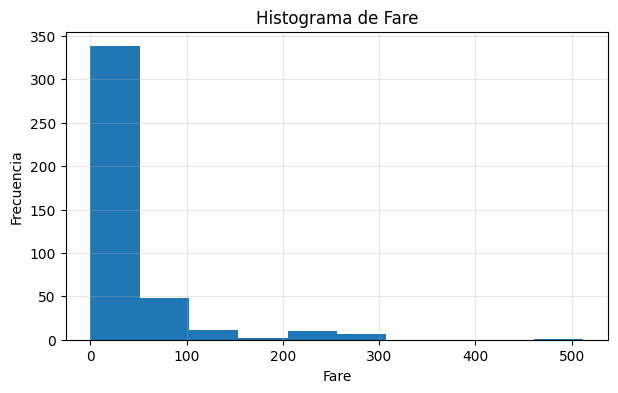

In [12]:
columnas = ['Age', 'SibSp', 'Parch', 'Fare']

for columna in columnas:
    plt.figure(figsize=(7, 4))
    plt.hist(df[columna])
    plt.title(f"Histograma de {columna}")
    plt.xlabel(columna)
    plt.ylabel("Frecuencia")
    plt.grid(alpha=0.3)

    plt.show()

In [13]:
df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,0.363636,2.265550,30.272590,0.447368,0.392344,35.627188
std,0.481622,0.841838,14.181209,0.896760,0.981429,55.907576
min,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,0.000000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1.000000,3.000000,76.000000,8.000000,9.000000,512.329200


Hay sesgo hacia la derecha en todas las variables y además hay presencia de atípicos, por lo que aquellas que tengan valores faltantes se colocará la mediana como default y se aplicará escala logarítmica para normalizar los datos.

##### Tratamiento de nulos.

In [14]:
mediana_age = df['Age'].median()
df['Age'] = df['Age'].fillna(mediana_age)
mediana_fare = df['Fare'].median()
df['Fare'] = df['Fare'].fillna(mediana_fare)

##### Aplicación de escala logarítmica.

In [15]:
for columna in columnas:
    df[columna] = np.log1p(df[columna])

##### Estandarización.

In [16]:
scaler = StandardScaler()
df[columnas] = scaler.fit_transform(df[columnas])

##### Codificación de variables categóricas.

In [17]:
columnas_categoricas = ['Pclass', 'Sex', 'Embarked']

df = pd.get_dummies(df, columns=columnas_categoricas, drop_first=True, dtype=int)

##### DataFrame final.

In [18]:
df.head()

,Survived,Age,SibSp,Parch,Fare,Pclass_2,Pclass_3,Sex_male,Embarked_Q,Embarked_S
0,0,0.461545,-0.633681,-0.497692,-0.867031,0,1,1,1,0
1,1,0.986118,1.038512,-0.497692,-0.969149,0,1,0,0,1
2,0,1.458985,-0.633681,-0.497692,-0.669252,1,0,1,1,0
3,0,0.048854,-0.633681,-0.497692,-0.773647,0,1,1,0,1
4,1,-0.293207,1.038512,1.140590,-0.443786,0,1,0,0,1


##### Separación de etiquetas.

In [19]:
target = 'Survived'
X = df.drop(columns=[target])
y = df[target]

##### Datos de entrenamiento y prueba.

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)

##### Creación de DataFrame no etiquetados.

In [21]:
# Porcentajes de datos etiquetados
porcentajes = [0.05, 0.10, 0.20]

for p in porcentajes:
    X_labeled, X_unlabeled, y_labeled, y_unlabeled = train_test_split(X_train, y_train, train_size=p, random_state=0, stratify=y_train)
    
    # Dataframe etiquetado
    df_labeled = X_labeled.copy()
    df_labeled[target] = y_labeled
    
    # Dataframe no etiquetado
    df_unlabeled = X_unlabeled.copy()
    df_unlabeled[target] = -1   # -1 indica dato sin etiqueta
    
    # Unir etiquetados con no etiquetados
    df_train_semi = pd.concat([df_labeled, df_unlabeled], axis=0)
    
    # Guardar CSV
    porcentaje_nombre = int(p * 100)
    df_train_semi.to_csv(f"train_{porcentaje_nombre}_porc.csv", index=False)

##### Guardando los datos de prueba.

In [22]:
df_test = X_test.copy()
df_test[target] = y_test
df_test.to_csv('test.csv', index=False)

##### Comparación de modelo supervisado y no supervisado.

SVM: Aprende una frontera de decisión usando únicamente datos etiquetados.  
El Transductive SVM: Su idea principal es que la frontera de decisión no solo debe separar correctamente los datos etiquetados, sino también pasar por una zona donde haya pocos datos no etiquetados.  
Laplacian SVM: Ese grafo conecta observaciones similares. Luego se usa el Laplaciano del grafo para penalizar predicciones muy diferentes entre puntos cercanos.

Comparación entre SVM supervisado y Transductive SVM

| Aspecto | SVM supervisado | Transductive SVM |
|---|---|---|
| Usa datos etiquetados | Sí | Sí |
| Usa datos no etiquetados | No | Sí |
| Objetivo | Maximizar margen con etiquetas conocidas | Maximizar margen considerando también puntos sin etiqueta |
| Tipo de aprendizaje | Supervisado | Semi-supervisado |
| Ventaja | Más simple y estable | Puede mejorar si hay pocos datos etiquetados |
| Desventaja | Desaprovecha datos sin etiqueta | Más complejo y más costoso computacionalmente |

Comparación entre SVM supervisado y Laplacian SVM

| Aspecto | SVM supervisado | Laplacian SVM |
|---|---|---|
| Usa datos etiquetados | Sí | Sí |
| Usa datos no etiquetados | No | Sí |
| Usa estructura geométrica | No explícitamente | Sí |
| Usa grafo de similitud | No | Sí |
| Objetivo | Separar clases con máximo margen | Separar clases y mantener suavidad en el grafo |
| Ventaja | Más simple | Aprovecha la forma de la distribución de datos |
| Desventaja | Puede necesitar muchas etiquetas | Depende mucho de cómo se construye el grafo |